In [1]:
import os
from libs.permutation import *
from libs.metis_backend import partitioning_graph_metis
from libs.utils import load_mtx

In [2]:
data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
k_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_k.mtx")
m_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_m.mtx")

print("Using data_dir:", data_dir)

# Load matrices
MATRIX_K = load_mtx(k_matrix_path, 'K')
MATRIX_M = load_mtx(m_matrix_path, 'M')

if MATRIX_K is None or MATRIX_M is None:
    raise RuntimeError("Matrix load failed; check file paths printed above.")

print(f"Loaded: K | shape={MATRIX_K.shape}, nnz={MATRIX_K.nnz}")
#print(f"Loaded: M | shape={MATRIX_M.shape}, nnz={MATRIX_M.nnz}")

Using data_dir: /home/operation/reps/FEM-Graph-Partitioning-Toolkit-Multilevel-METIS-/data
Loaded: K | shape=(960, 960), nnz=30282


In [3]:
DOF_PER_NODE = 3 # Degrees of freedom per node (e.g., 3 for 3D problems)

# Parameters for the coarsening ---------------------------------------------------------------
COARSEN_LIMIT = 300 # Stop coarsening when graph has <= this many nodes
MAX_LEVELS = 10 # Maximum number of coarsening levels
WEIGHT = 'weight' # Edge weight attribute to use for coarsening (e.g., 'weight' or 'weight_k')
STRATEGY = 'sorted'  # Options: 'random', 'sorted', 'modified', 'light'
COARSEN_RATIO = 2  # Stop if reduction ratio > 0.80
K_TARGET = 32  # number of parts desired

# Parameters for the annealling ---------------------------------------------------------------
BALANCE_LAMBDA = 2 # Balance constraint penalty weight (higher means more balanced partitions)
NUM_READS = 1000 # Number of reads/samples to draw from the quantum annealer (e.g., D-Wave)
BALANCE_TOLERANCE = 2.0  # Allow ±5% variation in partition sizes (like METIS ubfactor)

# Permuting matrices

In [5]:
matrix_m_permuted, matrix_k_permuted, permutation = permute_mk(
    matrix_m = MATRIX_M,
    matrix_k = MATRIX_K,
    dof_per_node = DOF_PER_NODE,
    coarsen_limit=COARSEN_LIMIT, 
    max_levels=MAX_LEVELS, 
    weight=WEIGHT, 
    strategy=STRATEGY,
    coarsen_ratio=COARSEN_RATIO, 
    max_node_weight=None, 
    k_target=K_TARGET, 
    balance_lambda=BALANCE_LAMBDA, 
    num_reads=NUM_READS, 
    balance_tolerance=BALANCE_TOLERANCE,

    permuting_strategy='qa_partitioning'
)

matrix_m_permuted_metis, matrix_k_permuted_metis, permutation_metis = permute_mk(
    matrix_m = MATRIX_M,
    matrix_k = MATRIX_K,
    dof_per_node = DOF_PER_NODE,
    coarsen_limit=COARSEN_LIMIT, 
    max_levels=MAX_LEVELS, 
    weight=WEIGHT, 
    strategy=STRATEGY,
    coarsen_ratio=COARSEN_RATIO, 
    max_node_weight=None, 
    k_target=K_TARGET, 
    balance_lambda=BALANCE_LAMBDA, 
    num_reads=NUM_READS, 
    balance_tolerance=BALANCE_TOLERANCE,

    permuting_strategy='metis_partitioning'
)

Graphs created: G_K with 320 nodes and 1523 edges

--- Finished Coarsening using Heavy Edge Matching ---
Coarsening produced 2 levels. Final graph has 167 nodes and 732 edges.

 --- Finished Partitioning using Quantum Annealing ---
Partitioning on coarsest graph produced 32 parts.

--- Finished Uncoarsening ---
Final partition on original graph has 32 parts.

--- Finished Permuting Matrices ---
Original K Shape: (960, 960), Original K Nonzeros: 30282
Permuted K Shape: (960, 960), Permuted K Nonzeros: 30282
Graphs created: G_K with 320 nodes and 1523 edges

--- Finished Coarsening using Heavy Edge Matching ---
Coarsening produced 2 levels. Final graph has 167 nodes and 732 edges.
[metis] nparts=32, |V|=167, |E|=732

 --- Finished Partitioning using METIS ---
Partitioning on coarsest graph produced 32 parts.

--- Finished Uncoarsening ---
Final partition on original graph has 32 parts.

--- Finished Permuting Matrices ---
Original K Shape: (960, 960), Original K Nonzeros: 30282
Permuted 

## Visualize Block Structure

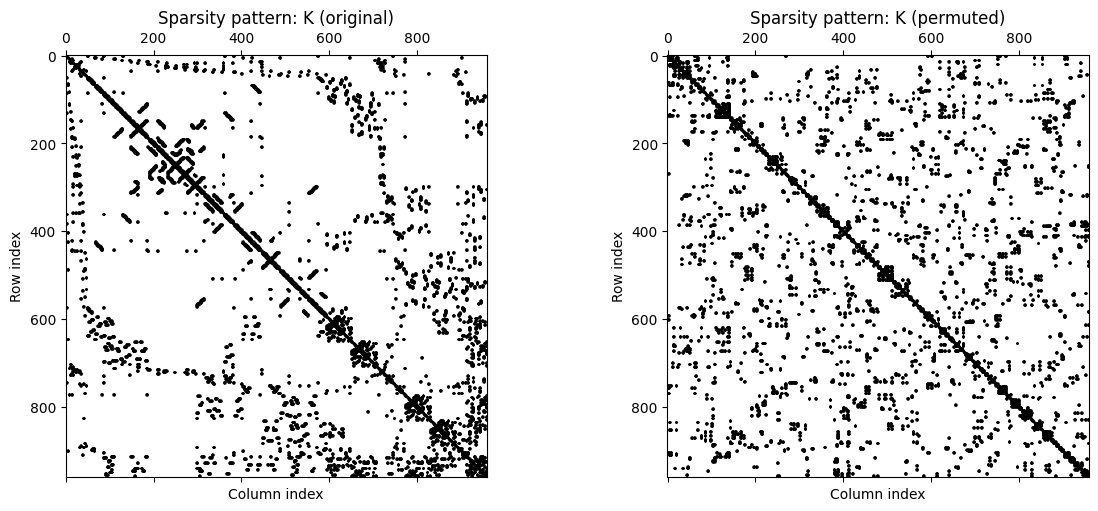

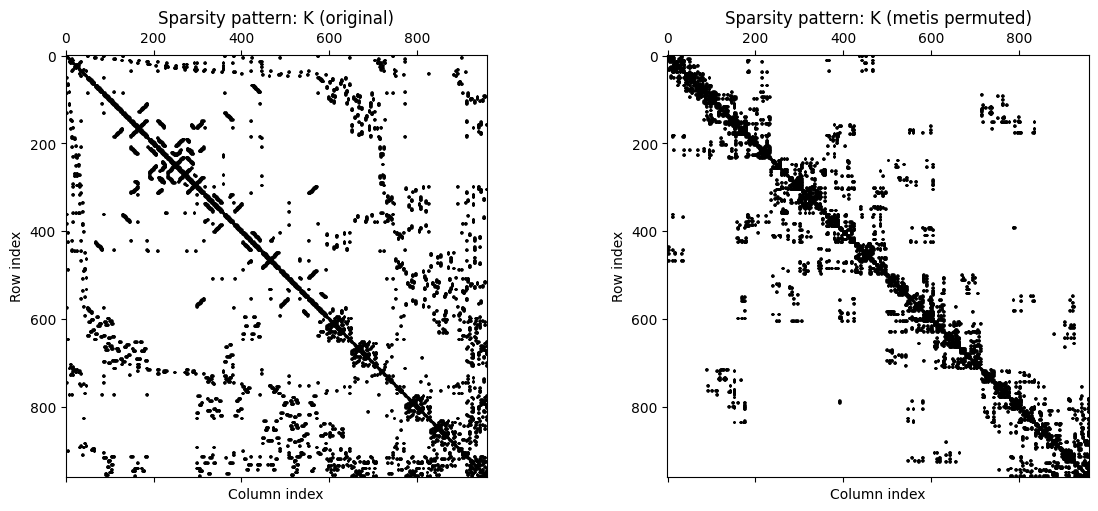

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Sparsity pattern: K (original)'}, xlabel='Column index', ylabel='Row index'>,
        <Axes: title={'center': 'Sparsity pattern: K (metis permuted)'}, xlabel='Column index', ylabel='Row index'>],
       dtype=object))

In [ ]:
# Original K and Permuted K
plot_sparsity_panel(
    MATRIX_K,
    matrix_k_permuted,
    name_a="K (original)",
    name_b="K (permuted)"
)

plot_sparsity_panel(
    MATRIX_K,
    matrix_k_permuted_metis,
    name_a="K (original)",
    name_b="K (metis permuted)"
)

# Evaluating result of permuted matrix

In [6]:
import numpy as np
from scipy import sparse

def _as_csr(A):
    return A.tocsr() if sparse.issparse(A) else sparse.csr_matrix(A)

def check_permutation_matrix_relation(A_original, A_permuted, permutation, n_samples=100000, seed=0, tol=0.0):
    """
    Verifies (by random entry checks) that:
        A_permuted[i, j] == A_original[permutation[i], permutation[j]]
    This is the relationship produced by permuting rows/cols with the same permutation.
    """
    A0 = _as_csr(A_original)
    Ap = _as_csr(A_permuted)
    p = np.asarray(permutation, dtype=int)

    n = A0.shape[0]
    assert A0.shape == Ap.shape
    assert p.shape[0] == n

    rng = np.random.default_rng(seed)
    ii = rng.integers(0, n, size=n_samples)
    jj = rng.integers(0, n, size=n_samples)

    mismatches = 0
    max_abs_err = 0.0
    for i, j in zip(ii, jj):
        a_ref = A0[p[i], p[j]]
        a_got = Ap[i, j]
        err = float(abs(a_ref - a_got))
        if err > tol:
            mismatches += 1
            if err > max_abs_err:
                max_abs_err = err

    print("Permutation check:")
    print(f"  samples={n_samples}, mismatches={mismatches}, max_abs_err={max_abs_err}")
    return mismatches, max_abs_err

def sparsity_metrics(A, band: int = 200):
    """Simple structural metrics that can be computed from the matrix alone."""
    A = _as_csr(A)
    coo = A.tocoo()
    r = coo.row
    c = coo.col
    d = np.abs(r - c)
    bw = int(d.max()) if d.size else 0
    nnz = int(A.nnz)
    n = int(A.shape[0])

    in_band = int(np.count_nonzero(d <= band)) if d.size else 0
    frac_in_band = (in_band / nnz) if nnz else 1.0

    return {
        "n": n,
        "nnz": nnz,
        "bandwidth": bw,
        f"nnz_within_|i-j|<={band}": in_band,
        f"frac_within_|i-j|<={band}": frac_in_band,
    }

# (1) Correctness / equivalence claim (matrix-only):
# If K' = P K P^T and M' = P M P^T (same P), then any downstream computation that
# depends only on the linear algebra is equivalent up to reordering of unknowns.
check_permutation_matrix_relation(MATRIX_K, matrix_k_permuted, permutation)
check_permutation_matrix_relation(MATRIX_K, matrix_k_permuted_metis, permutation_metis)

#check_permutation_matrix_relation(MATRIX_M, matrix_m_permuted, permutation)

print("\nEquivalence note:")
print("  Using a simultaneously permuted system (K', M') is mathematically the same as (K, M),")
print("  just with the unknowns reordered. Results map back by the inverse permutation.")

# (2) Iteration-count intuition (matrix-only):
# For unpreconditioned Krylov methods like CG/GMRES, a pure permutation does NOT change eigenvalues,
# so in exact arithmetic the iteration count should be essentially the same.
# Speedups usually come from *implementation effects* (cache locality) or *preconditioners*
# (ILU/IC fill-in depends strongly on ordering). These can be assessed via structure metrics.
print("\nStructural metrics (original vs permuted):")
for name, A0, Ap in [
    ("K", MATRIX_K, matrix_k_permuted),
    ("K_metis", MATRIX_K, matrix_k_permuted_metis),
    #("M", MATRIX_M, matrix_m_permuted),
]:
    m0 = sparsity_metrics(A0, band=200)
    mp = sparsity_metrics(Ap, band=200)
    print(f"\n{name} original:")
    for k, v in m0.items():
        print(f"  {k}: {v}")
    print(f"{name} permuted:")
    for k, v in mp.items():
        print(f"  {k}: {v}")

print("\nInterpretation:")
print("  - Same nnz and same spectrum/condition number -> unpreconditioned iterations ~ same.")
print("  - Lower bandwidth / higher diagonal concentration after permutation often helps factorization")
print("    and incomplete preconditioners, which can reduce iterations in practice.")

Permutation check:
  samples=100000, mismatches=0, max_abs_err=0.0
Permutation check:
  samples=100000, mismatches=0, max_abs_err=0.0

Equivalence note:
  Using a simultaneously permuted system (K', M') is mathematically the same as (K, M),
  just with the unknowns reordered. Results map back by the inverse permutation.

Structural metrics (original vs permuted):

K original:
  n: 960
  nnz: 30282
  bandwidth: 899
  nnz_within_|i-j|<=200: 17070
  frac_within_|i-j|<=200: 0.5637012086387954
K permuted:
  n: 960
  nnz: 30282
  bandwidth: 878
  nnz_within_|i-j|<=200: 16640
  frac_within_|i-j|<=200: 0.5495013539396341

K_metis original:
  n: 960
  nnz: 30282
  bandwidth: 899
  nnz_within_|i-j|<=200: 17070
  frac_within_|i-j|<=200: 0.5637012086387954
K_metis permuted:
  n: 960
  nnz: 30282
  bandwidth: 686
  nnz_within_|i-j|<=200: 27246
  frac_within_|i-j|<=200: 0.8997424212403408

Interpretation:
  - Same nnz and same spectrum/condition number -> unpreconditioned iterations ~ same.
  - Lowe